<a href="https://colab.research.google.com/github/pacheco110798/DataAnalysis/blob/main/AuditoriayTransformacionDeDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

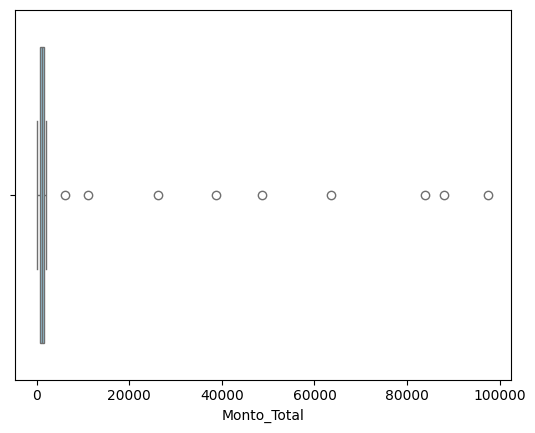

IQR:  1034.435


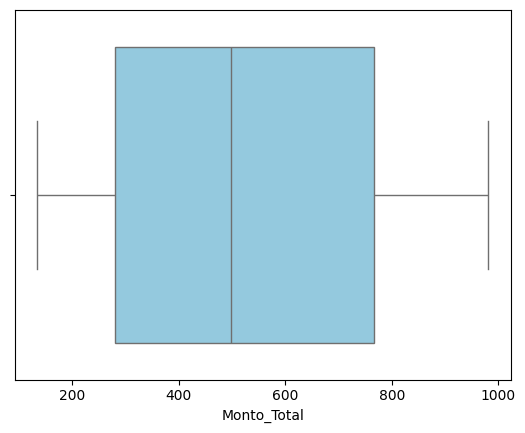

Resumen Ejecutivo
                  ventas_totales  ticket_promedio  transacciones
Ciudad_Venta                                                    
BOGOTA                   3745.99       416.221111              9
CIUDAD DE MEXICO         4266.81       474.090000              9
GUADALAJARA              2494.71       498.942000              5
LIMA                     4932.22       616.527500              8
MERIDA                   5209.94       473.630909             11
MONTERREY                9378.78       625.252000             15
QUERETARO                4027.11       503.388750              8
SAN LUIS POTOSI          6486.42       540.535000             12


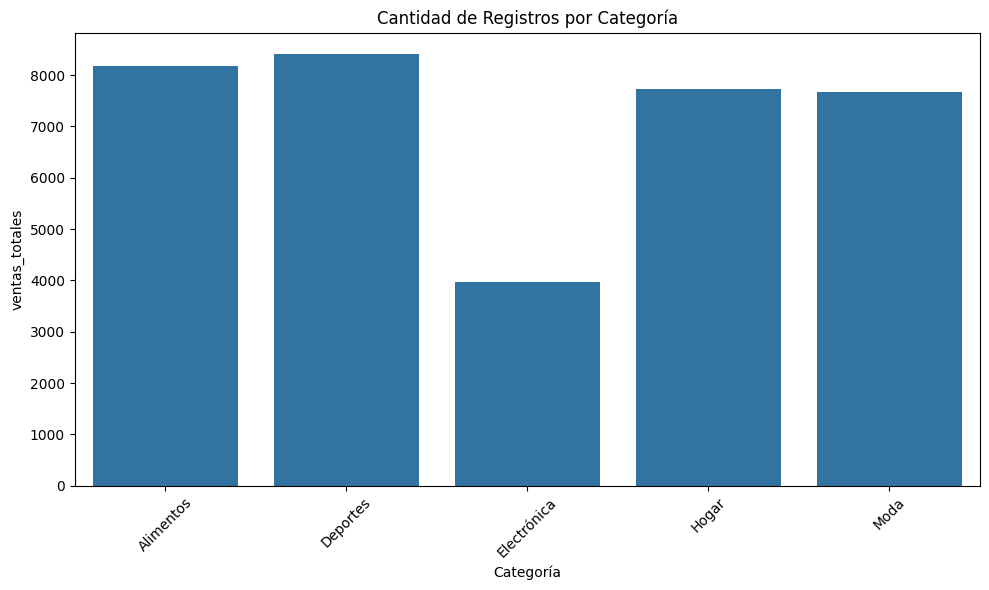

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#importar dataset
df = pd.read_csv("dataset_practica1.csv", encoding="latin1", sep=";")

#transformaciín de fecha de registro a formato estándar
df["Fecha_Registro"] = pd.to_datetime(df["Fecha_Registro"], format="mixed", errors="coerce")
df["Fecha_Registro"] = df["Fecha_Registro"].dt.strftime("%d/%m/%Y")

#transformar monto total de tipo string a tipo float
df["Monto_Total"] = pd.to_numeric(
    df["Monto_Total"]
    .str.replace(r"\$", "", regex=True)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False),
    errors="coerce"
)

#filtrar solo los registros no nulos
df = df[df["Fecha_Registro"].notna()]


#filtrar registros duplicados
# duplicates = df[
#     df.duplicated(subset=["ID_Venta"])
# ]
# print(duplicates)

#filtrar registros duplicados
df = df.drop_duplicates(
  subset=["ID_Venta"]
)

sns.boxplot(x=df['Monto_Total'], color='skyblue')
plt.show()

Q1 = df['Monto_Total'].quantile(0.25)
Q3 = df['Monto_Total'].quantile(0.75)

#calcular IQR
IQR = Q3 - Q1

print('IQR: ', IQR)

df = df[
    df["Monto_Total"] <= IQR
]

sns.boxplot(x=df_filtered['Monto_Total'], color='skyblue')
plt.show()
df["Ciudad_Venta"].unique()

df["Ciudad_Venta"] = (
    df["Ciudad_Venta"]
    .str.strip()
    .str.upper()
    .str.replace("Á", "A")
    .str.replace("É", "E")
    .str.replace("Í", "I")
    .str.replace("Ó", "O")
    .str.replace("Ú", "U")
)

avg = df['Monto_Total'].mean()

df["Ticket_Premium"] =  df['Monto_Total'] > avg
# print(df.head())

resumen_ciudad = (
    df.groupby("Ciudad_Venta")
    .agg(
        ventas_totales=("Monto_Total", "sum"),
        ticket_promedio=("Monto_Total", "mean"),
        transacciones=("Monto_Total", "count"),
    )
)

print("Resumen Ejecutivo")
print(resumen_ciudad)

categoria = (
    df.groupby("Categoria")
    .agg(
        ventas_totales=("Monto_Total", "sum"),
    )
)

plt.figure(figsize=(10, 6))
sns.barplot(data=categoria, x="Categoria", y="ventas_totales")

plt.title("Cantidad de Registros por Categoría")
plt.xlabel("Categoría")
plt.ylabel("ventas_totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


